In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from astropy.stats import sigma_clip
from scipy.stats import binned_statistic

from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

N_train = 446  N_test = 112
Test RMSE: 0.1868
Test  MAE: 0.1435
Test   R2: 0.8287


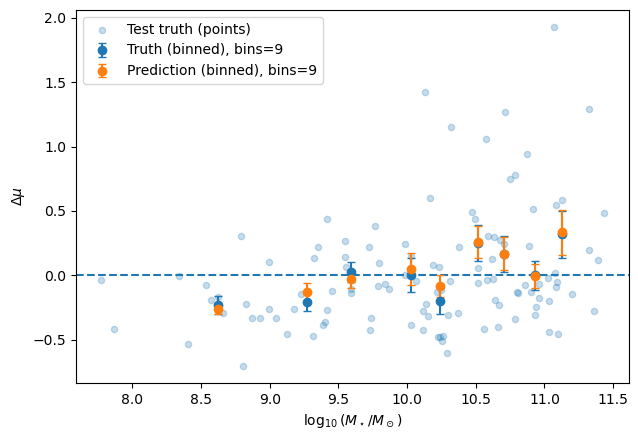

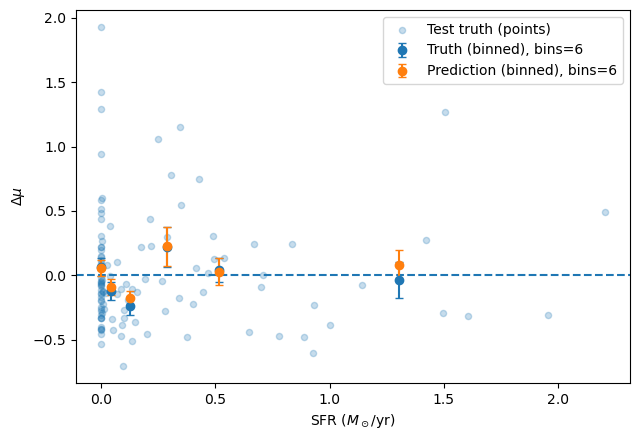

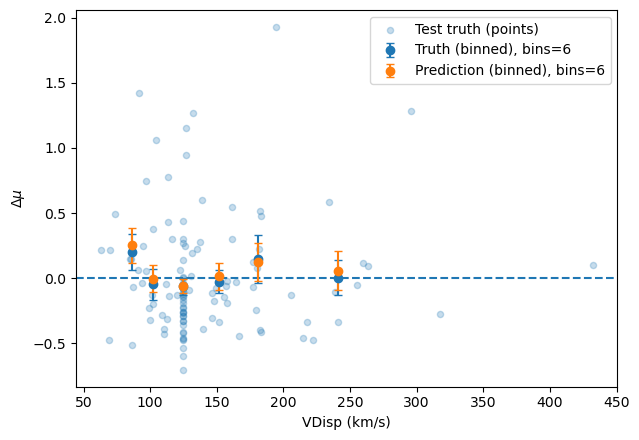

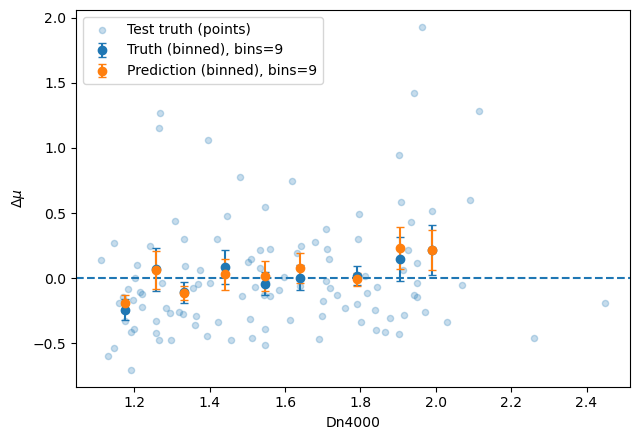

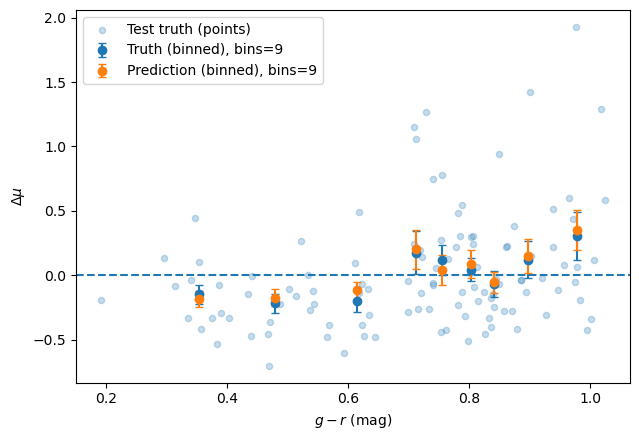

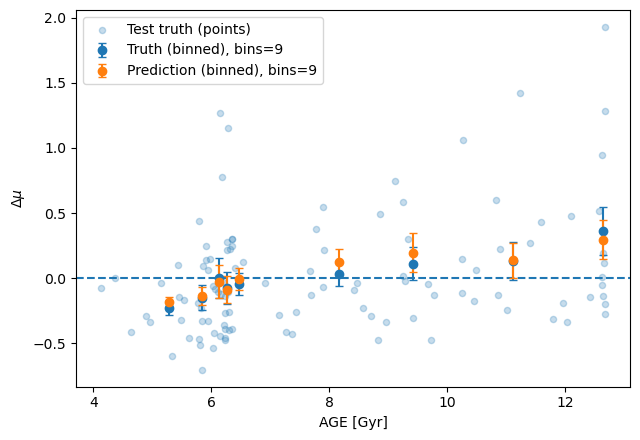

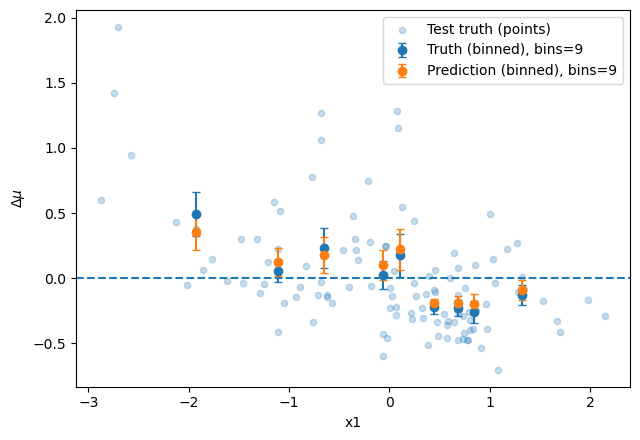

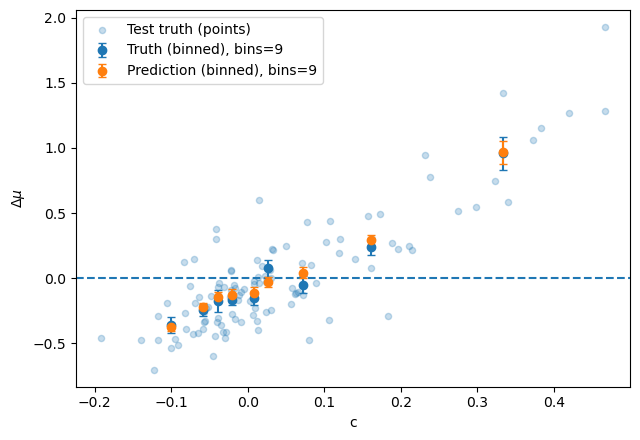

In [3]:
# -----------------------------
# 1) Load your data
# -----------------------------
csv_path = "/Users/pittsburghgraduatestudent/repos/myc21_first_paper/ZTF_DESI_ml_work/ZTF_DESI_data/ZTF_residuals_centered_no_x1_no_c_v2.csv"
df = pd.read_csv(csv_path)

# ---------------------------------------------------------------------------------------
# 2) Choose target we're trying to predict + features that will be used in training
# ---------------------------------------------------------------------------------------
target_col = "residual_centered"

feature_cols = [
    "LOGMSTAR",
    "SFR",
    "VDISP",
    "DN4000",
    "SDSS_g_minus_r",
    "AGE",
    "x1",
    "c"
]

# Building table that ends up selecting only the feature_cols
# and target_col from the data frame we read "df"
df_model = df[feature_cols + [target_col]].copy()


# Separating data into train and test splits here. 
X = df_model[feature_cols]
y = df_model[target_col]

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42
)

# -----------------------------
# 4) Build + train model pipeline
# -----------------------------
model = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="median")),
    ("rf", RandomForestRegressor(
        n_estimators=600,
        random_state=42,
        n_jobs=-1,
        # min_samples_leaf=20,   # trend-smoothing knob
    ))
])

model.fit(X_train, y_train)
y_pred_test = model.predict(X_test)

# -----------------------------
# 5) Basic regression metrics
# -----------------------------
rmse = np.sqrt(mean_squared_error(y_test, y_pred_test))
mae  = mean_absolute_error(y_test, y_pred_test)
r2   = r2_score(y_test, y_pred_test)

print(f"N_train = {len(X_train)}  N_test = {len(X_test)}")
print(f"Test RMSE: {rmse:.4f}")
print(f"Test  MAE: {mae:.4f}")
print(f"Test   R2: {r2:.4f}")


# -----------------------------
# 6) Trend recovery utilities
# -----------------------------
def choose_nbins(n_points, target_per_bin=12, min_bins=4, max_bins=12):
    """
    Choose a sensible number of bins for a given sample size.
    Example: N=112, target_per_bin=12 -> ~9 bins.
    """
    nb = int(np.floor(n_points / target_per_bin))
    return int(np.clip(nb, min_bins, max_bins))


def binned_means_quantile(x, y, n_bins, min_per_bin=8):
    """
    Quantile (equal-count) binning for x, then mean/SEM of y in each bin.

    Returns:
      centers, means, sems, edges
    or None if too few points.
    """
    x = np.asarray(x)
    y = np.asarray(y)

    m = np.isfinite(x) & np.isfinite(y)
    x = x[m]
    y = y[m]

    n = len(x)
    if n < (min_per_bin * 3):  # need at least a few bins worth
        return None

    # Quantile edges
    edges = np.quantile(x, np.linspace(0, 1, n_bins + 1))

    # Sometimes identical values cause repeated edges. Unique-ify edges.
    edges = np.unique(edges)
    if len(edges) < 4:  # would yield <3 bins
        return None

    bin_idx = np.digitize(x, edges[1:-1], right=False)

    centers, means, sems = [], [], []
    for b in range(len(edges) - 1):
        mask = bin_idx == b
        if mask.sum() < min_per_bin:
            continue
        xb = x[mask]
        yb = y[mask]
        centers.append(np.median(xb))
        means.append(np.mean(yb))
        sems.append(np.std(yb, ddof=1) / np.sqrt(mask.sum()))

    if len(centers) < 3:
        return None

    return np.array(centers), np.array(means), np.array(sems), edges


def plot_trend_recovery(feature_name, X_test_df, y_true, y_pred,
                        target_per_bin=12, min_per_bin=8,
                        min_bins=4, max_bins=12,
                        xlabel=None, ylabel=r"$\Delta\mu$",
                        show_points=True):
    """
    For a single feature:
      - scatter raw TEST truth
      - binned mean TEST truth
      - binned mean TEST prediction
    with bins chosen automatically from test-set size.
    """
    x = X_test_df[feature_name].to_numpy()

    # Choose bins based on usable points for THIS feature in the test set
    m = np.isfinite(x) & np.isfinite(y_true) & np.isfinite(y_pred)
    n_usable = int(m.sum())

    n_bins = choose_nbins(n_usable, target_per_bin=target_per_bin,
                          min_bins=min_bins, max_bins=max_bins)

    stats = binned_means_quantile(x[m], y_true[m], n_bins=n_bins, min_per_bin=min_per_bin)
    if stats is None:
        print(f"[skip] {feature_name}: usable={n_usable}, chosen_bins={n_bins} (too sparse for binning)")
        return

    centers_true, means_true, sems_true, edges = stats

    # Apply SAME edges to predictions
    x2 = x[m]
    yp2 = np.asarray(y_pred)[m]
    bin_idx = np.digitize(x2, edges[1:-1], right=False)

    centers_pred, means_pred, sems_pred = [], [], []
    for b in range(len(edges) - 1):
        mask = bin_idx == b
        if mask.sum() < min_per_bin:
            continue
        xb = x2[mask]
        yb = yp2[mask]
        centers_pred.append(np.median(xb))
        means_pred.append(np.mean(yb))
        sems_pred.append(np.std(yb, ddof=1) / np.sqrt(mask.sum()))

    # ---- Plot ----
    plt.figure(figsize=(6.5, 4.5))

    if show_points:
        plt.scatter(x[m], np.asarray(y_true)[m], s=20, alpha=0.25, label="Test truth (points)")

    plt.axhline(0.0, linestyle="--")

    plt.errorbar(
        centers_true, means_true, yerr=sems_true,
        fmt="o", capsize=3, label=f"Truth (binned), bins={len(centers_true)}"
    )

    plt.errorbar(
        np.array(centers_pred), np.array(means_pred), yerr=np.array(sems_pred),
        fmt="o", capsize=3, label=f"Prediction (binned), bins={len(centers_pred)}"
    )

    plt.xlabel(xlabel if xlabel else feature_name)
    plt.ylabel(ylabel)
    plt.legend()
    plt.tight_layout()
    plt.show()


# -----------------------------
# 7) Make trend-recovery plots
# -----------------------------
X_test_df = X_test.copy()  # already a DataFrame from train_test_split

pretty_labels = {
    "LOGMSTAR": r"$\log_{10}(M_\star/M_\odot)$",
    "SFR": r"SFR ($M_\odot$/yr)",
    "VDISP": r"VDisp (km/s)",
    "DN4000": r"Dn4000",
    "SDSS_g_minus_r": r"$g-r$ (mag)",
    "AGE": r"AGE [Gyr]"
}

for feat in feature_cols:
    plot_trend_recovery(
        feat,
        X_test_df=X_test_df,
        y_true=y_test,
        y_pred=y_pred_test,
        target_per_bin=12,   # ~10–15 is good for N_test~112
        min_per_bin=8,       # allow bins to exist even in small samples
        min_bins=4,
        max_bins=12,
        xlabel=pretty_labels.get(feat, feat),
        ylabel=r"$\Delta\mu$",
        show_points=True
    )

N_train = 446  N_test = 112
Test RMSE: 0.1868
Test  MAE: 0.1435
Test   R2: 0.8287


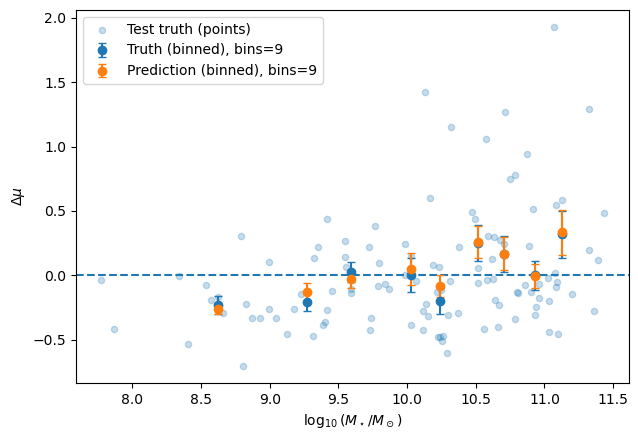

In [4]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score


# -----------------------------
# 1) Load your data
# -----------------------------
csv_path = "/Users/pittsburghgraduatestudent/repos/myc21_first_paper/ZTF_DESI_ml_work/ZTF_DESI_data/ZTF_residuals_centered_no_x1_no_c_v2.csv"
df = pd.read_csv(csv_path)

# ---------------------------------------------------------------------------------------
# 2) Choose target we're trying to predict + features that will be used in training
# ---------------------------------------------------------------------------------------
target_col = "residual_centered"

feature_cols = [
    "LOGMSTAR",
    "SFR",
    "VDISP",
    "DN4000",
    "SDSS_g_minus_r",
    "AGE",
    "x1",
    "c"
]

# Building table that ends up selecting only the feature_cols
# and target_col from the data frame we read "df"
df_model = df[feature_cols + [target_col]].copy()


# Separating data into train and test splits here. 
X = df_model[feature_cols]
y = df_model[target_col]

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42
)

# -----------------------------
# 4) Build + train model pipeline
# -----------------------------
model = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="median")),
    ("rf", RandomForestRegressor(
        n_estimators=600,
        random_state=42,
        n_jobs=-1,
        # min_samples_leaf=20,   # trend-smoothing knob
    ))
])

model.fit(X_train, y_train)
y_pred_test = model.predict(X_test)

# -----------------------------
# 5) Basic regression metrics
# -----------------------------
rmse = np.sqrt(mean_squared_error(y_test, y_pred_test))
mae  = mean_absolute_error(y_test, y_pred_test)
r2   = r2_score(y_test, y_pred_test)

print(f"N_train = {len(X_train)}  N_test = {len(X_test)}")
print(f"Test RMSE: {rmse:.4f}")
print(f"Test  MAE: {mae:.4f}")
print(f"Test   R2: {r2:.4f}")


# -----------------------------
# 6) Trend recovery utilities (LOGMSTAR only)
# -----------------------------
def choose_nbins(n_points, target_per_bin=12, min_bins=4, max_bins=12):
    """
    Choose a sensible number of bins for a given sample size.
    Example: N=112, target_per_bin=12 -> ~9 bins.
    """
    nb = int(np.floor(n_points / target_per_bin))
    return int(np.clip(nb, min_bins, max_bins))


def binned_means_quantile(x, y, n_bins, min_per_bin=8):
    """
    Quantile (equal-count) binning for x, then mean/SEM of y in each bin.

    Returns:
      centers, means, sems, edges
    or None if too few points.
    """
    x = np.asarray(x)
    y = np.asarray(y)

    m = np.isfinite(x) & np.isfinite(y)
    x = x[m]
    y = y[m]

    n = len(x)
    if n < (min_per_bin * 3):  # need at least a few bins worth
        return None

    # Quantile edges
    edges = np.quantile(x, np.linspace(0, 1, n_bins + 1))

    # Sometimes identical values cause repeated edges. Unique-ify edges.
    edges = np.unique(edges)
    if len(edges) < 4:  # would yield <3 bins
        return None

    bin_idx = np.digitize(x, edges[1:-1], right=False)

    centers, means, sems = [], [], []
    for b in range(len(edges) - 1):
        mask = bin_idx == b
        if mask.sum() < min_per_bin:
            continue
        xb = x[mask]
        yb = y[mask]
        centers.append(np.median(xb))
        means.append(np.mean(yb))
        sems.append(np.std(yb, ddof=1) / np.sqrt(mask.sum()))

    if len(centers) < 3:
        return None

    return np.array(centers), np.array(means), np.array(sems), edges


# -----------------------------
# 7) Trend recovery plot for LOGMSTAR only
# -----------------------------
feature_name = "LOGMSTAR"

x = X_test[feature_name].to_numpy()
y_true = np.asarray(y_test)
y_pred = np.asarray(y_pred_test)

# Keep only rows where x, y_true, y_pred are finite
m = np.isfinite(x) & np.isfinite(y_true) & np.isfinite(y_pred)
n_usable = int(m.sum())

# Choose an appropriate number of bins based on test set size
n_bins = choose_nbins(n_usable, target_per_bin=12, min_bins=4, max_bins=12)

# Compute binned trend for truth in the test set
stats = binned_means_quantile(x[m], y_true[m], n_bins=n_bins, min_per_bin=8)
if stats is None:
    raise RuntimeError(f"Not enough usable data to bin {feature_name}. usable={n_usable}, bins={n_bins}")

centers_true, means_true, sems_true, edges = stats

# Apply SAME edges to predictions
x2 = x[m]
yp2 = y_pred[m]
bin_idx = np.digitize(x2, edges[1:-1], right=False)

centers_pred, means_pred, sems_pred = [], [], []
for b in range(len(edges) - 1):
    mask = bin_idx == b
    if mask.sum() < 8:
        continue
    xb = x2[mask]
    yb = yp2[mask]
    centers_pred.append(np.median(xb))
    means_pred.append(np.mean(yb))
    sems_pred.append(np.std(yb, ddof=1) / np.sqrt(mask.sum()))

# ---- Plot ----
plt.figure(figsize=(6.5, 4.5))

# Raw test set points (truth)
plt.scatter(x[m], y_true[m], s=20, alpha=0.25, label="Test truth (points)")

# Horizontal zero line
plt.axhline(0.0, linestyle="--")

# Binned truth
plt.errorbar(
    centers_true, means_true, yerr=sems_true,
    fmt="o", capsize=3, label=f"Truth (binned), bins={len(centers_true)}"
)

# Binned predictions
plt.errorbar(
    np.array(centers_pred), np.array(means_pred), yerr=np.array(sems_pred),
    fmt="o", capsize=3, label=f"Prediction (binned), bins={len(centers_pred)}"
)

plt.xlabel(r"$\log_{10}(M_\star/M_\odot)$")
plt.ylabel(r"$\Delta\mu$")
plt.legend()
plt.tight_layout()
plt.show()

558 SNe before paper-based quality cuts.
558 SNe after paper-based quality cuts.
558 SNe after LOGMSTAR cut.
558 SNe after SFR cut.
558 SNe after VDISP cut.
558 SNe after DN4000 cut.
558 SNe after SDSS g-r cut.
558 SNe after AGE cut.


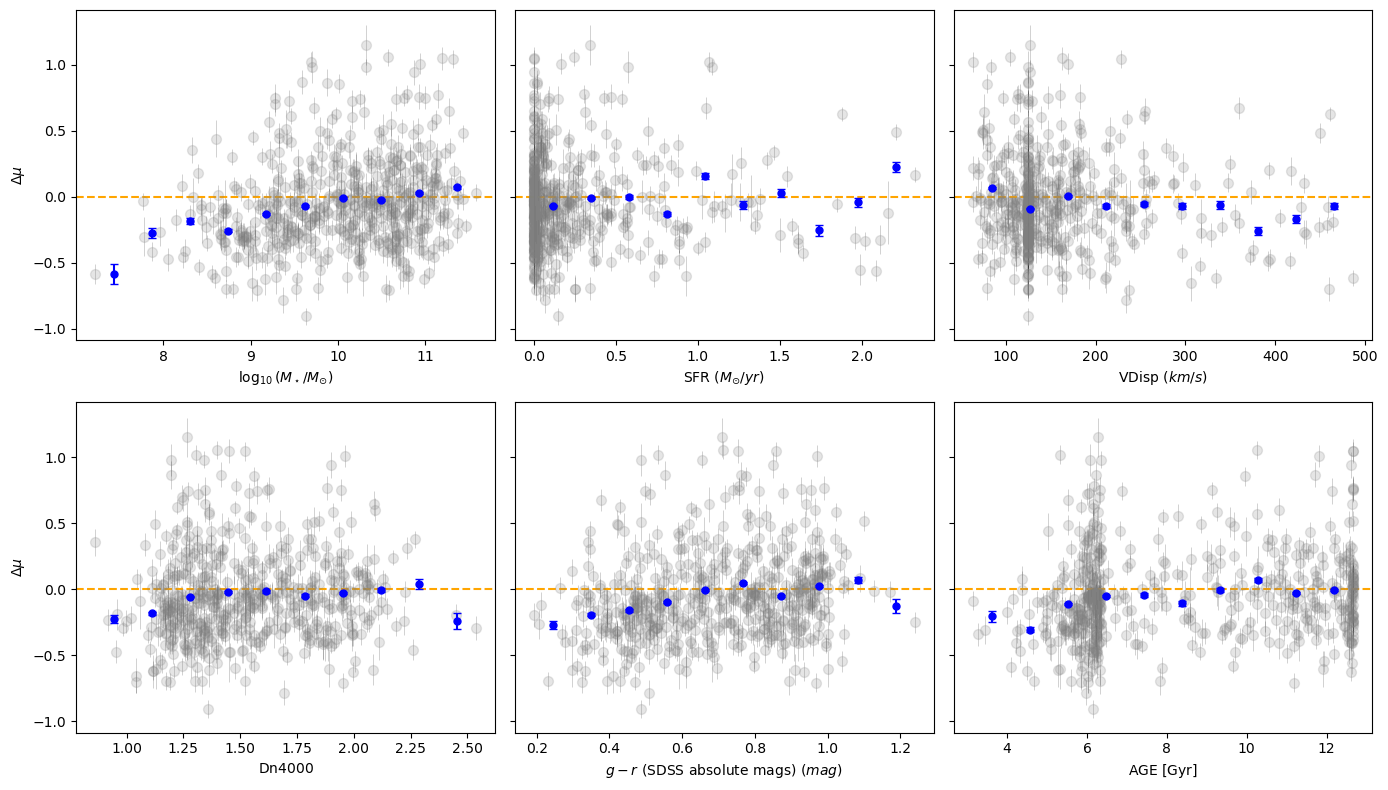

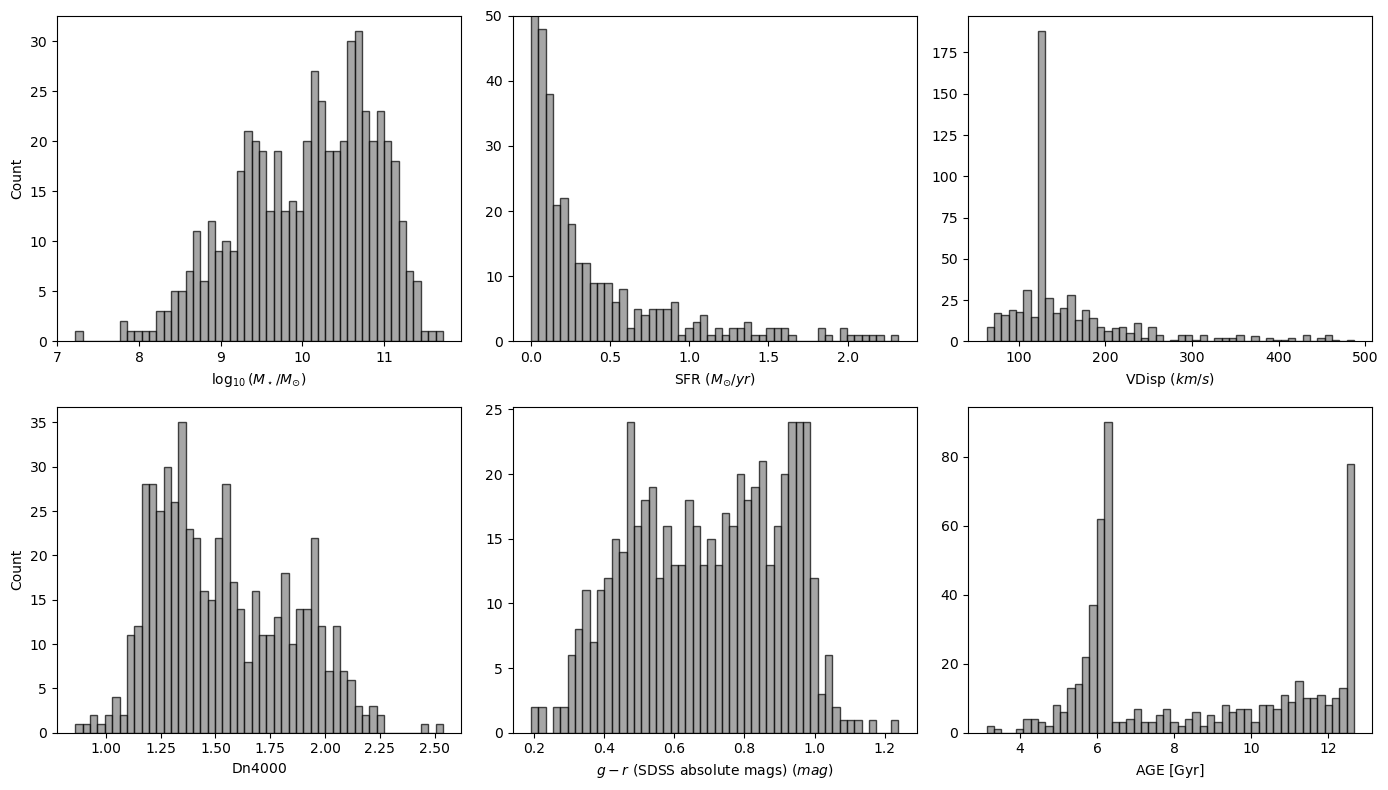

In [5]:
df = pd.read_csv("/Users/pittsburghgraduatestudent/repos/myc21_first_paper/ZTF_DESI_ml_work/ZTF_DESI_data/ZTF_residuals_centered_no_x1_no_c_v2.csv")

# -------------------------------------------------------
# DATA FILTER - Paper lccoverage_flag and fitquality_flag
# -------------------------------------------------------
print(len(df), "SNe before paper-based quality cuts.")
df = df[(df["lccoverage_flag"] == 1) & (df["fitquality_flag"] == 1)]
print(len(df), "SNe after paper-based quality cuts.")

# --------------------------------------
# Create g - r host-galaxy color
# --------------------------------------
df["SDSS_g_minus_r"] = df["ABSMAG01_SDSS_G"] - df["ABSMAG01_SDSS_R"]

# Read the Error Collumn for the distance modulus measurements.
yerr_all = df["sigma_mu_meas"]

nbins = 10

# Helper funciton that plots the scatter and error bars. 
# ax - matplotlib axis where the plots will be drawn. 
# mask - the mask that selects which rows to use. 
# xcol - name of the df collumn to put on the x axis. Note residuals are always on the y-axis here.

def scatter_with_errors(ax, mask, xcol, nbins=None):
    # Raw values
    x = df.loc[mask, xcol].values
    y = df.loc[mask, "residual_centered"].values
    yerr = yerr_all.loc[mask].values

    # --- sigma clipping in y (vertical axis) ---
    clipped = sigma_clip(y, sigma=3, maxiters=1)
    mask_clip = ~clipped.mask  # True = keep point

    # apply clipping to x, y, yerr
    x = x[mask_clip]
    y = y[mask_clip]
    yerr = yerr[mask_clip]


    # --- scatter cloud ---
    ax.scatter(x, y, **point_kwargs)

    # --- individual error bars ---
    # Important to note that the way that this function works we will be drawing 
    # an error bar line from y - yerr to y + yerr. Where y_err = sigma_i
    ax.errorbar(
        x, y, yerr=yerr,
        fmt="none",
        ecolor="black",
        elinewidth=0.5,
        alpha=0.25,
        zorder=2,
    )

    # horizontal reference
    ax.axhline(0, linestyle="--", color="orange")

    # --- BINNING WITH ERROR PROPAGATION ---
    # NOTE: we set the number of bins here. 

    # binned_statistic is a function tha takes (x, values, ststics, bins, range)
    # x - an array of positions along the x-axis.
    # values - the vaules on which the statistics are computed inside each bin. 
    # NOTE: here we want to just count the number of points in each bin on the 
    # horizontal axis of our plots. Therefore we parse "x" as both the argument and the 
    # value and simply choose "count" as our statistics option. 
    # bin_edges is an array of bin boundaries
    # binnumber - the index for which data point each bin belongs in.
    # This is done mostly becaue the data on the horizontal axis is not ranked so
    # we have to give it an identifier when we do our bin statistics later on. 
    # Bin centers are just calcualted as the middle points between one bin edge and another.
    
    _, bin_edges, binnumber = binned_statistic(x, x, statistic="count", bins=10) 
    bin_centers = 0.5 * (bin_edges[:-1] + bin_edges[1:])

    # Creating arrays for ht residuals. 
    binned_y = []
    binned_yerr = []

    # Just a fancy way of saying "for each bin"
    # We end up appending the data and error means into
    # an array. 
    for i in range(1, len(bin_edges)):
        in_bin = binnumber == i

        # We end up finding data and errro associated
        # with the number of bin that we are in. 
        y_bin = y[in_bin]
        err_bin = yerr[in_bin]
    
        # inverse-variance weights
        w = 1.0 / (err_bin**2)
    
        # weighted mean
        y_mean = np.sum(w * y_bin) / np.sum(w)
    
        # propagated error on the mean
        err_mean = 1.0 / np.sqrt(np.sum(w))
    
        binned_y.append(y_mean)
        binned_yerr.append(err_mean)

    ax.errorbar(
        bin_centers,
        binned_y,
        yerr=binned_yerr,
        fmt="o",
        color="blue",
        markersize=5,
        capsize=3,
        zorder = 5 # Keeps the data looking on top
    )

# **************************************
# --------------------------------------
# Set up 2x3 grid - RESIDUALS + ERRORS + BINS w/t ERRORS
# --------------------------------------
# **************************************


fig, axes = plt.subplots(2, 3, figsize=(14, 8), sharey=True)
axes = axes.flatten()

point_kwargs = dict(alpha=0.2, s=50, color="grey", zorder=3)   

# --------------------------------------
# 1) LOGMSTAR
# --------------------------------------
ax = axes[0]

# finite values mask (same as before)
mask_logm = np.isfinite(df["LOGMSTAR"])
print(np.sum(mask_logm), "SNe after LOGMSTAR cut.")

# Use helper function with binning ON
scatter_with_errors(ax, mask_logm, "LOGMSTAR", nbins)

# Axis labels
ax.set_xlabel(r"$\log_{10}(M_\star / M_{\odot})$")
ax.set_ylabel(r"$\Delta \mu$")

# --------------------------------------
# 2) SFR (cut SFR > 2.5)
# --------------------------------------
ax = axes[1]

# Exclude SFR > 2.5
mask_sfr = (df["SFR"] <= 2.5)
print(np.sum(mask_sfr), "SNe after SFR cut.")

scatter_with_errors(ax, mask_sfr, "SFR", nbins=nbins)

ax.set_xlabel(r"${\rm SFR}\ (M_{\odot}/yr)$")

# --------------------------------------
# 3) VDISP
# --------------------------------------
ax = axes[2]

mask_vdisp = np.isfinite(df["VDISP"])
print(np.sum(mask_vdisp), "SNe after VDISP cut.")

scatter_with_errors(ax, mask_vdisp, "VDISP", nbins=nbins)

ax.set_xlabel(r"${\rm VDisp }\  (km/s) $")


# --------------------------------------
# 4) DN4000  (cut DN4000 < 0.5)
# --------------------------------------
ax = axes[3]

# keep only finite values AND DN4000 >= 0.5
mask_dn4000 = df["DN4000"] >= 0.5
print(np.sum(mask_dn4000), "SNe after DN4000 cut.")

scatter_with_errors(ax, mask_dn4000, "DN4000", nbins=nbins)

ax.set_xlabel(r"${\rm Dn4000}$")
ax.set_ylabel(r"$\Delta \mu$")


# --------------------------------------
# 5) SDSS g - r
# --------------------------------------
ax = axes[4]

mask_sdssq = np.isfinite(df["SDSS_g_minus_r"])
print(np.sum(mask_sdssq), "SNe after SDSS g-r cut.")

scatter_with_errors(ax, mask_sdssq, "SDSS_g_minus_r", nbins=nbins)

ax.set_xlabel(r"$g - r~{\rm (SDSS ~ absolute ~ mags)}\ (mag)$")


# --------------------------------------
# 6) AGE  (cut AGE < 2)
# --------------------------------------
ax = axes[5]

# keep only finite AGE and AGE >= 2
mask_age = df["AGE"] >= 2

print(np.sum(mask_age), "SNe after AGE cut.")

scatter_with_errors(ax, mask_age, "AGE", nbins=nbins)

ax.set_xlabel(r"${\rm AGE}\ [{\rm Gyr}]$")

# --------------------------------------
# Global cosmetics
# --------------------------------------

fig.tight_layout()
plt.show()

# **************************************
# --------------------------------------
# Set up 2x3 grid - HISTOGRAMS
# --------------------------------------
# **************************************

fig, axes = plt.subplots(2, 3, figsize=(14, 8))
axes = axes.flatten()

# Global Histogram Parameters which are included here 
# in order to keep the histogram the same. 
hist_kwargs = dict(bins=50, alpha=0.7, edgecolor="black", color="grey")

# --------------------------------------
# 1) LOGMSTAR
# --------------------------------------
# mask_logm is already defined when the weighed bins were being plotted
# (in the above code)
# mask_logm is an array of true and false values where "True" means
# the data points are to be kept. 

# when we write df.loc[mask_logm, "LOGMSTAR"], we are selecting
# only the LOGMSTAR values where the mask is True.

# its important to match the masks we defined previously so that we end up. 

axes[0].hist(df.loc[mask_logm, "LOGMSTAR"].values, **hist_kwargs)
axes[0].set_xlabel(r"$\log_{10}(M_\star / M_{\odot})$")
axes[0].set_ylabel("Count")

# --------------------------------------
# 2) SFR (same cuts as above)
# --------------------------------------
axes[1].hist(df.loc[mask_sfr, "SFR"].values, **hist_kwargs)
axes[1].set_ylim(0, 50)
axes[1].set_xlabel(r"${\rm SFR}\ (M_{\odot}/yr)$")

# --------------------------------------
# 3) VDISP
# --------------------------------------
axes[2].hist(df.loc[mask_vdisp, "VDISP"].values, **hist_kwargs)
axes[2].set_xlabel(r"${\rm VDisp }\  (km/s) $")

# --------------------------------------
# 4) DN4000  
# --------------------------------------
axes[3].hist(df.loc[mask_dn4000, "DN4000"].values, **hist_kwargs)
axes[3].set_xlabel(r"${\rm Dn4000}$")
axes[3].set_ylabel("Count")

# --------------------------------------
# 5) SDSS g - r
# --------------------------------------
axes[4].hist(df.loc[mask_sdssq, "SDSS_g_minus_r"].values, **hist_kwargs)
axes[4].set_xlabel(r"$g - r~{\rm (SDSS ~ absolute ~ mags)}\ (mag)$")

# --------------------------------------
# 6) AGE  (cut AGE < 2)
# --------------------------------------
axes[5].hist(df.loc[mask_age, "AGE"].values, **hist_kwargs)
axes[5].set_xlabel(r"${\rm AGE}\ [{\rm Gyr}]$")

# --------------------------------------
# Global cosmetics
# --------------------------------------

fig.tight_layout()
plt.show()
